In [1]:
import disk_ecc as original
import disk_ecc_warp_setstructure as mine

import numpy as np
import bettermoments as bm

import matplotlib.pyplot as plt

In [2]:
def matrix_mine(x, y, z, warp, twist, inc_, PA_):

    warp = warp[None, :, None]
    #print("warp.shape" + str(warp.shape))
    twist = twist[None, :, None]
    #print("twist.shape" + str(twist.shape))

    cosw = np.cos(warp)
    sinw = np.sin(warp)
    

    cost = np.cos(twist)
    sint = np.sin(twist)

    cosPA = np.cos(PA_)
    sinPA = np.sin(PA_)

    cosi = np.cos(inc_)
    sini = np.sin(inc_)

    '''making sure twist occurs before warp'''

    #x_t = x*cost + y*(-sint)
    #y_t = x*sint + y*cost

    #xp = x_t
    #yp = y_t*cosw + z*(-sinw)
    #zp = y_t*sinw + z*cosw

    #xp = x*(-sinPA*sint*cosi + cosPA*cost)+ y*((-sinPA*cosi*cost - sint*cosPA)


    xp = x*(-sinPA*sint*cosi + cosPA*cost) + y*((-sinPA*cosi*cost - sint*cosPA)*cosw + sinPA*sini*sinw) + z*(-(-sinPA*cosi*cost - sint*cosPA)*sinw + sinPA*sini*cosw)
    yp = x*(sinPA*cost + sint*cosPA*cosi) + y*((-sinPA*sint + cosPA*cosi*cost)*cosw - sini*sinw*cosPA) + z*(-(-sinPA*sint + cosPA*cosi*cost)*sinw - sini*cosPA*cosw)
    zp = y*(sini*cost*cosw + sinw*cosi) + z*(-sini*sinw*cost + cosi*cosw)

    return xp, yp, zp


In [348]:
r = np.linspace(0, 100, 100)
phi = np.linspace(0, np.pi*2, 100)
z = np.linspace(-25, 25, 50)

R, Phi, Z = np.meshgrid(r, phi, z)

In [349]:
#xl = np.linspace (-100, 100, 100)
#yl = np.linspace (-100, 100, 100)
#zl = np.linspace (-100, 100, 50)

#X, Y, Z = np.meshgrid(xl, yl, zl)


In [350]:
def cart2pol(x, y):
    rho = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    return(rho, phi)

def pol2cart(rho, phi):
    x = rho * np.cos(phi)
    y = rho * np.sin(phi)
    return(x, y)

In [ ]:
def w_func_sky(r0, dr, a_in, a_out, r):
    #r0 = self.w_r0
    #dr = self.w_dr
    '''
    if type == "w":
        a_in = self.w_i
        a_out = self.inc
        print("a_out " + str(a_out))
        print("a_in" + str(a_in))

    elif type == "pa":
        a_in = self.pa
        a_out = self.pos
        print("a_out " + str(a_out))
        print("a_in" + str(a_in))
    '''
    r0 = 1.0 if r0 is None else r0
    dr = 1.0 if dr is None else dr

    exp  = np.radians(a_out - (a_out - a_in) / (1 + np.exp((r - r0)/(0.1 * dr))))
    return exp

In [352]:
inc = 89/2
incl = np.deg2rad(inc)
az =0
azi = np.deg2rad(az)
r0 = 55
dr = 10
w_i = 70/2
w_pa = 0

In [353]:
#R, Phi = cart2pol(X,Y)
X, Y = pol2cart(R, Phi)

twist = w_func_sky(r0, dr, w_pa, az, r)
warp = w_func_sky(r0, dr, w_i, inc, r)

X_w, Y_w, Z_w = matrix_mine(X, Y, Z, warp, twist, incl, azi)

In [354]:
X_w.shape

(100, 100, 50)

(-100.0, 100.0)

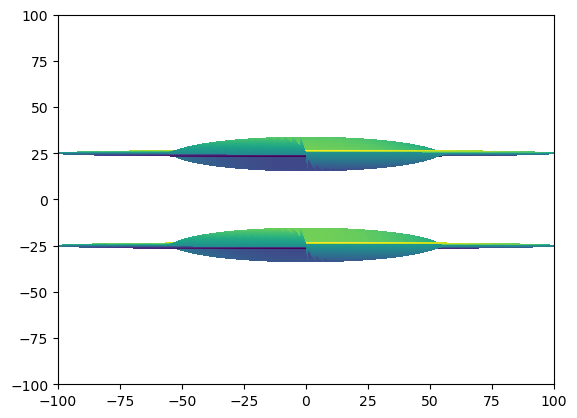

In [355]:
plt.pcolor(X_w[:,:,0], Y_w[:,:,0], Z_w[:,:,0])
plt.pcolor(X_w[:,:,-1], Y_w[:,:,-1], Z_w[:,:,-1])
plt.xlim(-100,100)
plt.ylim(-100,100)

In [356]:
import sympy as sp

In [357]:
def Rx(angle):
    return sp.Matrix([
    [1,       0,              0],
    [0,       sp.cos(angle), -sp.sin(angle)],
    [0,       sp.sin(angle),  sp.cos(angle)],
])

def Ry(angle):
    return sp.Matrix([
    [ sp.cos(angle), 0, sp.sin(angle)],
    [0,              1, 0],
    [-sp.sin(angle), 0, sp.cos(angle)],
])

def Rz(angle):
    return sp.Matrix([
    [sp.cos(angle), -sp.sin(angle), 0],
    [sp.sin(angle),  sp.cos(angle), 0],
    [0,              0,             1],
])

In [358]:
### Working this through step by step. Starting with twist
#rotation around z-axis for a face-on disk. 


def matrix_twist(x, y, z, warp, twist, inc_, PA_, t):

    t = np.deg2rad(t)

    warp = warp[None, :, None]
    #print(warp)
    #print("warp.shape" + str(warp.shape))
    twist = twist[None, :, None]
    #print(twist)
    #print("twist.shape" + str(twist.shape))

    cosw = np.cos(warp)
    sinw = np.sin(warp)
    

    cost = np.cos(twist)
    sint = np.sin(twist)
    #cost = np.cos(t)
    #print(cost)
    #sint = np.sin(t)
    #print(sint)

    cosPA = np.cos(PA_)
    sinPA = np.sin(PA_)

    cosi = np.cos(inc_)
    sini = np.sin(inc_)

    '''making sure twist occurs before warp'''

    #x_t = x*cosPA*cost - y*cosPA*sint
    #y_t = x*cosPA*sint + y*cosPA*cost

    x_t = x*cost - y*sint
    y_t = x*sint + y*cost

    y_w = y*cosw - z*sinw
    z_w = y*sinw + z*cosw

    #xp = x*(-sinPA*sint*cosi + cosPA*cost) + y*((-sinPA*cosi*cost - sint*cosPA)*cosw + sinPA*sini*sinw) + z*(-(-sinPA*cosi*cost - sint*cosPA)*sinw + sinPA*sini*cosw)
    #yp = x*(sinPA*cost + sint*cosPA*cosi) + y*((-sinPA*sint + cosPA*cosi*cost)*cosw - sini*sinw*cosPA) + z*(-(-sinPA*sint + cosPA*cosi*cost)*sinw - sini*cosPA*cosw)
    #zp = y*(sini*cost*cosw + sinw*cosi) + z*(-sini*sinw*cost + cosi*cosw)

    return x_t , y_w, z_w


In [362]:
inc = 84
incl = np.deg2rad(inc)
az =0
azi = np.deg2rad(az)
r0 = 55
dr = 10
w_i = 84
w_pa = 0

twist = w_func_sky(r0, dr, w_pa, az, r)
warp = w_func_sky(r0, dr, w_i, inc, r)

In [363]:
X_t, Y_t, Z_t = matrix_twist(X, Y, Z, warp, twist, incl, azi, 0)

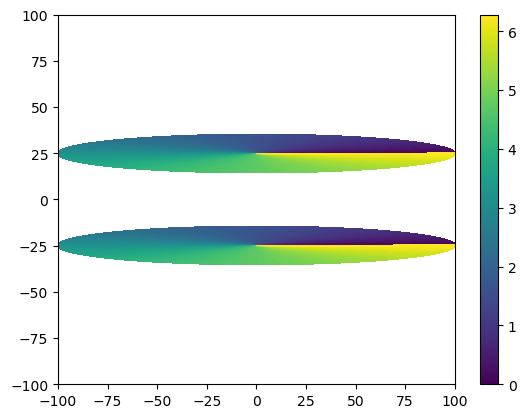

In [364]:
plt.pcolor(X_t[:,:,0], Y_t[:,:,0], Phi[:,:,0])
plt.pcolor(X_t[:,:,-1], Y_t[:,:,-1], Phi[:,:,-1])
#plt.plot(X_t[:,:,0], Y_t[:,:,0])
plt.xlim(-100,100)
plt.ylim(-100,100)

plt.colorbar()